# 02 — Exploratory Data Analysis
Revenue and profit patterns by category, region, segment, and time. Goal: surface at least 5 non-obvious, quantified insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../data/processed/superstore_clean.csv', parse_dates=['order_date'])
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sales,quantity,discount,profit,order_year,order_month,order_year_month,order_quarter,profit_margin,fulfillment_days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.9600,2,0.00,41.9136,2016,11,2016-11,2016Q4,0.1600,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.9400,3,0.00,219.5820,2016,11,2016-11,2016Q4,0.3000,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.6200,2,0.00,6.8714,2016,6,2016-06,2016Q2,0.4700,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,5,0.45,-383.0310,2015,10,2015-10,2015Q4,-0.4000,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.3680,2,0.20,2.5164,2015,10,2015-10,2015Q4,0.1125,7


## 1. Overall snapshot

In [2]:
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
overall_margin = total_profit / total_sales

print(f"Total sales:   ${total_sales:,.0f}")
print(f"Total profit:  ${total_profit:,.0f}")
print(f"Overall margin: {overall_margin:.2%}")
print(f"Orders: {df['order_id'].nunique():,}  |  Date range: {df['order_date'].min().date()} -> {df['order_date'].max().date()}")

Total sales:   $2,297,201
Total profit:  $286,397
Overall margin: 12.47%
Orders: 5,009  |  Date range: 2014-01-03 -> 2017-12-30


## 2. Sales & profit by category / sub-category

In [3]:
cat_summary = (
    df.groupby('category')[['sales', 'profit']]
      .sum()
      .assign(margin=lambda x: x['profit'] / x['sales'])
      .sort_values('sales', ascending=False)
)
cat_summary

,sales,profit,margin
category,,,
Technology,836154.0330,145454.9481,0.173957
Furniture,741999.7953,18451.2728,0.024867
Office Supplies,719047.0320,122490.8008,0.170352


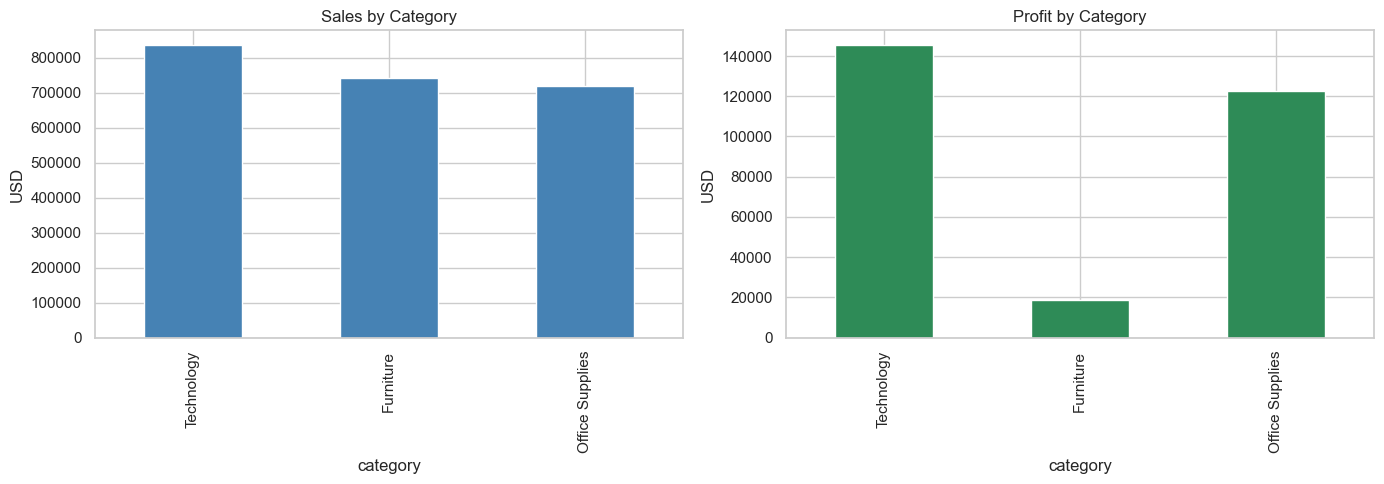

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cat_summary['sales'].plot(kind='bar', ax=axes[0], color='steelblue', title='Sales by Category')
cat_summary['profit'].plot(kind='bar', ax=axes[1], color='seagreen', title='Profit by Category')
for ax in axes:
    ax.set_ylabel('USD')
plt.tight_layout()
plt.savefig('../reports/figures/sales_profit_by_category.png', dpi=150)
plt.show()

In [5]:
subcat_summary = (
    df.groupby('sub_category')[['sales', 'profit']]
      .sum()
      .assign(margin=lambda x: x['profit'] / x['sales'])
      .sort_values('profit')
)
# Non-obvious insight candidate: sub-categories that are LOSING money despite high sales
losing_subcats = subcat_summary[subcat_summary['profit'] < 0]
print("Loss-making sub-categories:")
losing_subcats

Loss-making sub-categories:


,sales,profit,margin
sub_category,,,
Tables,206965.5320,-17725.4811,-0.085645
Bookcases,114879.9963,-3472.5560,-0.030228
Supplies,46673.5380,-1189.0995,-0.025477


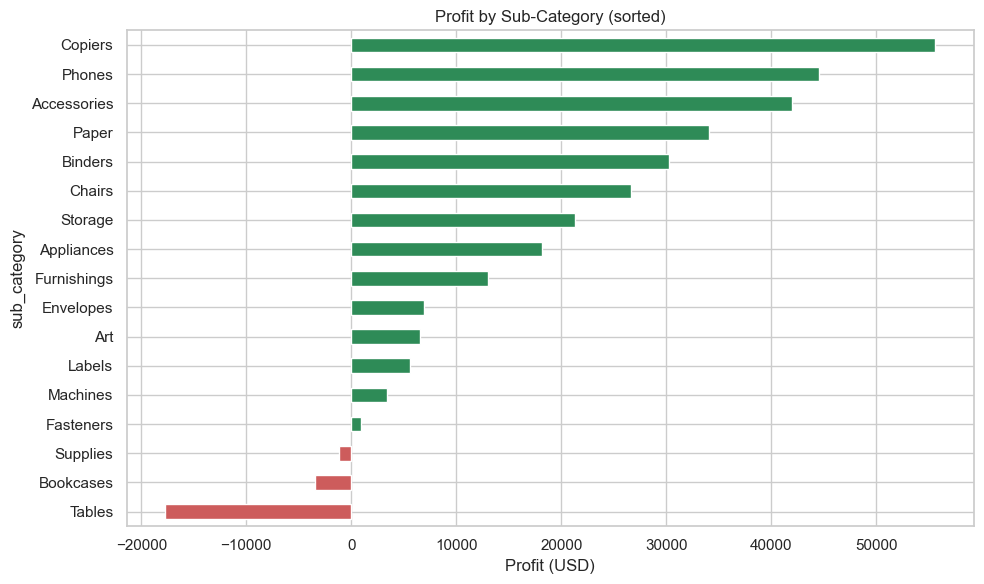

In [6]:
plt.figure(figsize=(10, 6))
subcat_summary['profit'].sort_values().plot(kind='barh', color=np.where(subcat_summary.sort_values('profit')['profit'] < 0, 'indianred', 'seagreen'))
plt.title('Profit by Sub-Category (sorted)')
plt.xlabel('Profit (USD)')
plt.tight_layout()
plt.savefig('../reports/figures/profit_by_subcategory.png', dpi=150)
plt.show()

## 3. Regional & segment performance

In [7]:
region_summary = (
    df.groupby('region')[['sales', 'profit']].sum()
      .assign(margin=lambda x: x['profit'] / x['sales'])
      .sort_values('sales', ascending=False)
)
region_summary

,sales,profit,margin
region,,,
West,725457.8245,108418.4489,0.149448
East,678781.2400,91522.7800,0.134834
Central,501239.8908,39706.3625,0.079216
South,391721.9050,46749.4303,0.119343


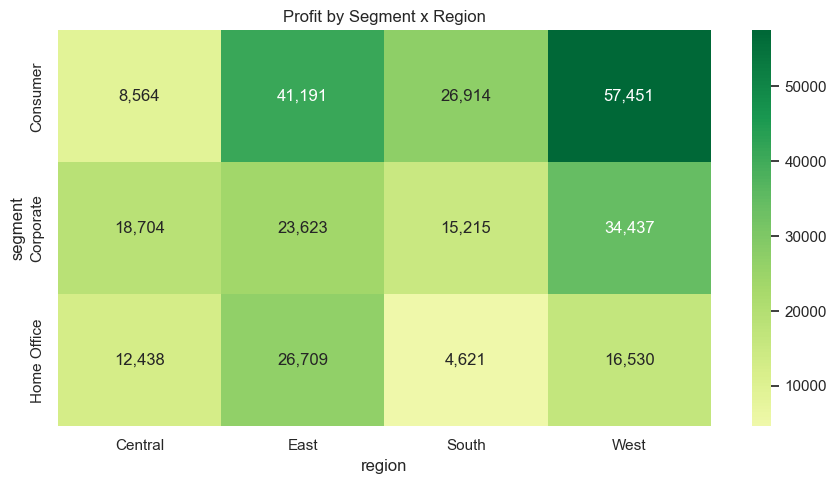

In [8]:
segment_region = df.pivot_table(index='segment', columns='region', values='profit', aggfunc='sum')
plt.figure(figsize=(9, 5))
sns.heatmap(segment_region, annot=True, fmt=',.0f', cmap='RdYlGn', center=0)
plt.title('Profit by Segment x Region')
plt.tight_layout()
plt.savefig('../reports/figures/profit_segment_region_heatmap.png', dpi=150)
plt.show()

## 4. Seasonality

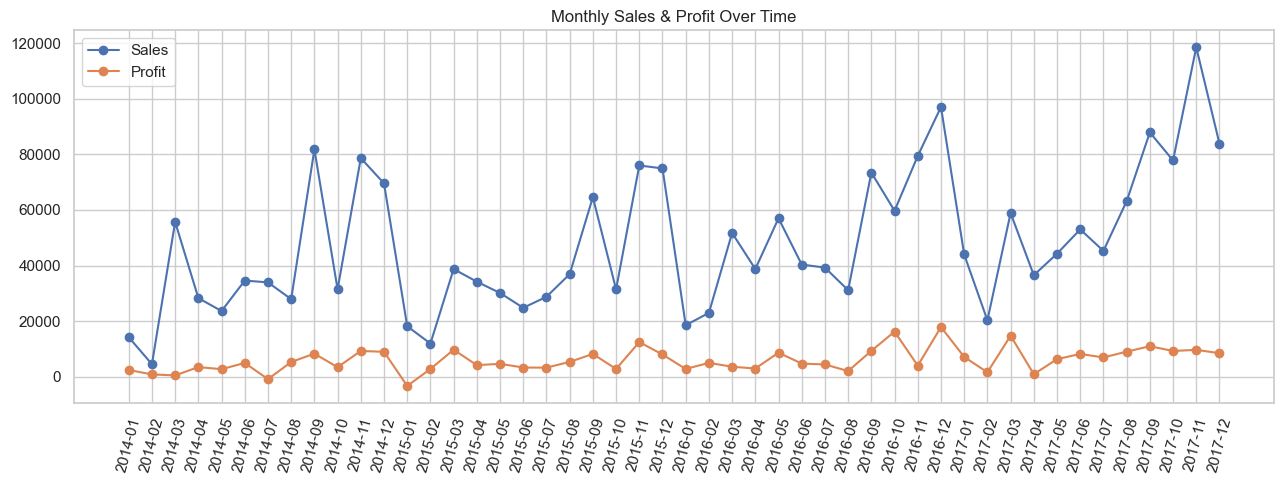

In [9]:
monthly = df.groupby('order_year_month')[['sales', 'profit']].sum().sort_index()
plt.figure(figsize=(13, 5))
plt.plot(monthly.index, monthly['sales'], marker='o', label='Sales')
plt.plot(monthly.index, monthly['profit'], marker='o', label='Profit')
plt.xticks(rotation=75)
plt.legend()
plt.title('Monthly Sales & Profit Over Time')
plt.tight_layout()
plt.savefig('../reports/figures/monthly_sales_profit.png', dpi=150)
plt.show()

In [10]:
month_avg = df.groupby('order_month')['sales'].sum()
peak_month = month_avg.idxmax()
trough_month = month_avg.idxmin()
lift = (month_avg[peak_month] - month_avg.mean()) / month_avg.mean()
print(f"Peak month: {peak_month} — {lift:.1%} above the average month")
print(f"Weakest month: {trough_month}")

Peak month: 11 — 84.1% above the average month
Weakest month: 2


## 5. Discount vs. profit — where does profit turn negative?

In [11]:
discount_bins = pd.cut(df['discount'], bins=[-0.01, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0])
discount_profit = df.groupby(discount_bins)['profit'].agg(['mean', 'sum', 'count'])
discount_profit

C:\Users\Aagam Shah\AppData\Local\Temp\ipykernel_25832\4077472677.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_profit = df.groupby(discount_bins)['profit'].agg(['mean', 'sum', 'count'])


,mean,sum,count
discount,,,
"(-0.01, 0.0]",66.900292,320987.6032,4798
"(0.0, 0.1]",96.055074,9029.1770,94
"(0.1, 0.2]",24.738824,91756.2975,3709
"(0.2, 0.3]",-45.679636,-10369.2774,227
"(0.3, 0.4]",-109.219691,-25448.1881,233
"(0.4, 0.5]",-298.695314,-22999.5392,77
"(0.5, 1.0]",-89.438144,-76559.0513,856


C:\Users\Aagam Shah\AppData\Local\Temp\ipykernel_25832\1393714658.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_means = df.groupby(discount_bins)['profit'].mean()


Average profit turns negative in the discount band: (0.2, 0.3]


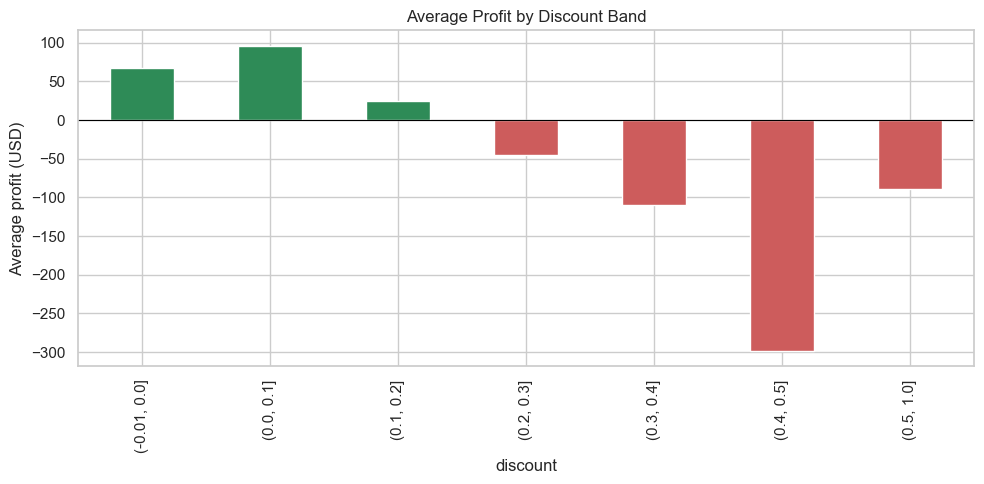

In [12]:
bin_means = df.groupby(discount_bins)['profit'].mean()
tipping_point = None
for b, val in bin_means.items():
    if val < 0:
        tipping_point = b
        break
print(f"Average profit turns negative in the discount band: {tipping_point}")

plt.figure(figsize=(10, 5))
bin_means.plot(kind='bar', color=np.where(bin_means < 0, 'indianred', 'seagreen'))
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('Average profit (USD)')
plt.title('Average Profit by Discount Band')
plt.tight_layout()
plt.savefig('../reports/figures/discount_vs_profit.png', dpi=150)
plt.show()

## 6. Top & bottom products

In [13]:
product_perf = df.groupby('product_name')[['sales', 'profit']].sum().sort_values('profit')
print("Bottom 10 products by profit:")
display(product_perf.head(10))
print("\nTop 10 products by profit:")
display(product_perf.tail(10).sort_values('profit', ascending=False))

Bottom 10 products by profit:


,sales,profit
product_name,,
Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704
Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730
Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,-2876.1156
Bush Advantage Collection Racetrack Conference Table,9544.725,-1934.3976
GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784
Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1299.1836
Balt Solid Wood Round Tables,6518.754,-1201.0581



Top 10 products by profit:


,sales,profit
product_name,,
Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7753.0390
Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836
Canon PC1060 Personal Laser Copier,11619.834,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4094.9766
Ativa V4110MDD Micro-Cut Shredder,7699.890,3772.9461
"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System,9367.290,3696.2820
Ibico EPK-21 Electric Binding System,15875.916,3345.2823


## 7. Customer repeat behavior

In [14]:
orders_per_customer = df.groupby('customer_id')['order_id'].nunique()
repeat_rate = (orders_per_customer > 1).mean()
print(f"Customers with more than one order: {repeat_rate:.1%}")
print(f"Average orders per customer: {orders_per_customer.mean():.2f}")

Customers with more than one order: 98.5%
Average orders per customer: 6.32


## Non-obvious insights summary (fill in the printed numbers above)
1. Sub-categories X and Y are losing money on an absolute basis despite meaningful sales volume.
2. Average profit turns negative once discount exceeds a specific threshold (see discount-band table).
3. [Region] generates the highest sales but not the highest margin — [Region] does.
4. Sales peak in [month] (a specific % above the average month) and dip in [month].
5. Only a specific % of customers place more than one order, showing where retention effort should focus.

Replace the bracketed placeholders with the exact values printed above before writing the README.